In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

## Загрузка датасета

In [37]:
df = pd.read_csv('dataset.csv')
print(df.head())
print(df.tail())
print(df.info())

  ticker commodity        date        open        high         low  \
0    GCF      Gold  2000-08-30  273.899994  273.899994  273.899994   
1    GCF      Gold  2000-08-31  274.799988  278.299988  274.799988   
2    GCF      Gold  2000-09-01  277.000000  277.000000  277.000000   
3    GCF      Gold  2000-09-05  275.799988  275.799988  275.799988   
4    GCF      Gold  2000-09-06  274.200012  274.200012  274.200012   

        close  volume  
0  273.899994       0  
1  278.299988       0  
2  277.000000       0  
3  275.799988       2  
4  274.200012       0  
      ticker  commodity        date        open        high         low  \
29051    PAF  Palladium  2024-06-17  876.500000  883.599976  876.500000   
29052    PAF  Palladium  2024-06-18  880.900024  880.900024  880.900024   
29053    PAF  Palladium  2024-06-20  905.000000  915.500000  905.000000   
29054    PAF  Palladium  2024-06-21  940.500000  950.000000  918.099976   
29055    PAF  Palladium  2024-06-24  981.500000  981.500000 

## Преобразование типов

In [38]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29056 entries, 0 to 29055
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ticker     29056 non-null  object        
 1   commodity  29056 non-null  object        
 2   date       29056 non-null  datetime64[ns]
 3   open       29056 non-null  float64       
 4   high       29056 non-null  float64       
 5   low        29056 non-null  float64       
 6   close      29056 non-null  float64       
 7   volume     29056 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(2)
memory usage: 1.8+ MB


## Подсчёт пустых элементов
Т. к. все строки "хорошие", то дополнительная очистка данных не нужна.

In [39]:
print(df.isna().sum())
print(df.isnull().sum())

ticker       0
commodity    0
date         0
open         0
high         0
low          0
close        0
volume       0
dtype: int64
ticker       0
commodity    0
date         0
open         0
high         0
low          0
close        0
volume       0
dtype: int64


## Подсчёт дупликатов
Т. к. дупликатов тоже нет (все записи в датасете уникальные), то и делать с ними ничего не надо.

In [28]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
29051    False
29052    False
29053    False
29054    False
29055    False
Length: 29056, dtype: bool

## Отклонения и аномалии

<Axes: >

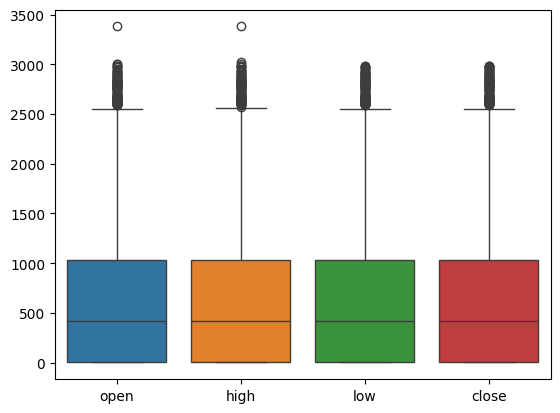

In [29]:
sns.boxplot(df[['open', 'high', 'low', 'close']])

<Axes: >

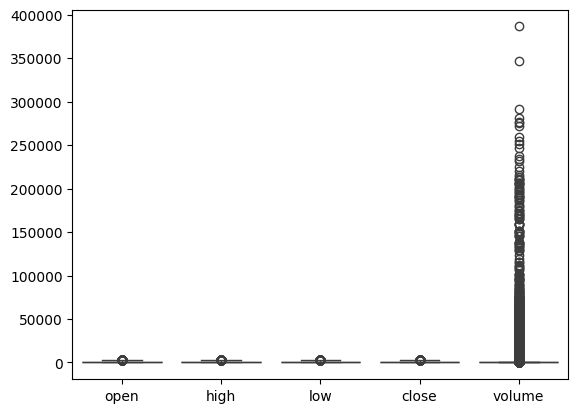

In [30]:
sns.boxplot(df)

## Описательная статистика

In [31]:
df.describe()

,date,open,high,low,close,volume
count,29056,29056.000000,29056.000000,29056.000000,29056.000000,29056.000000
mean,2012-08-20 22:31:11.365638656,602.717960,604.950990,600.343415,602.710099,1544.681305
min,2000-01-04 00:00:00,0.609000,0.609500,0.604000,0.604000,0.000000
25%,2006-05-30 00:00:00,7.825000,7.826500,7.821250,7.826500,3.000000
50%,2012-11-21 00:00:00,415.000000,416.550003,413.000000,414.824997,65.000000
75%,2018-09-07 00:00:00,1029.425018,1031.774963,1027.524994,1029.425018,366.000000
max,2024-06-24 00:00:00,3380.500000,3380.500000,2985.399902,2985.399902,386334.000000
std,NaN,647.833431,649.901786,645.449507,647.593915,12066.523773


In [40]:
print('Кол-во уникальных записей о кол-ве совершённых сделок в день: ', len(set(df['volume'])))

Кол-во уникальных записей о кол-ве совершённых сделок в день:  2938


Все остальные значения в силу своего типа (float) будут уникальными с большой вероятностью.

In [43]:
print(df['commodity'].value_counts())

commodity
Copper       5979
Silver       5976
Gold         5975
Palladium    5683
Platinum     5443
Name: count, dtype: int64


In [51]:
df['delta'] = df['high'] - df['low']

In [52]:
df.corr(numeric_only=True)

,open,high,low,close,volume,delta
open,1.000000,0.999956,0.999916,0.999909,0.037242,0.401189
high,0.999956,1.000000,0.999875,0.999931,0.037127,0.406089
low,0.999916,0.999875,1.000000,0.999951,0.037265,0.391597
close,0.999909,0.999931,0.999951,1.000000,0.037150,0.397720
volume,0.037242,0.037127,0.037265,0.037150,1.000000,0.006791
delta,0.401189,0.406089,0.391597,0.397720,0.006791,1.000000


## Графики

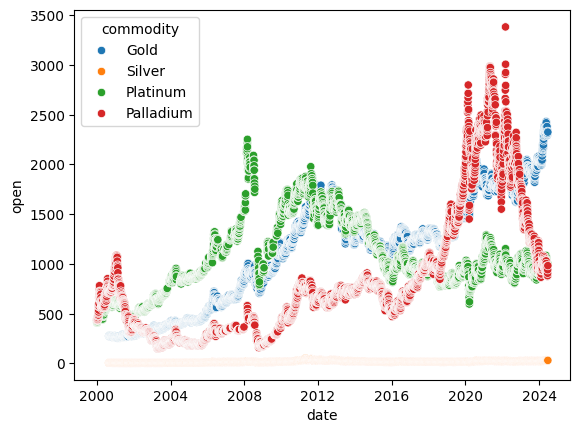

In [ ]:
sns.scatterplot(df[df['commodity']!="Copper"], x="date", y = "open", hue="commodity")
plt.title('Precious metals prices')
plt.show()

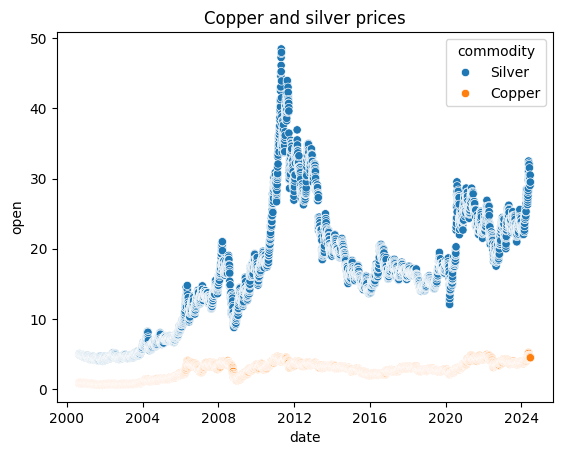

In [61]:
sns.scatterplot(df[(df["commodity"]=="Silver") | (df['commodity']=='Copper')], x='date', y='open', hue="commodity")
plt.title('Copper and silver prices')
plt.show()

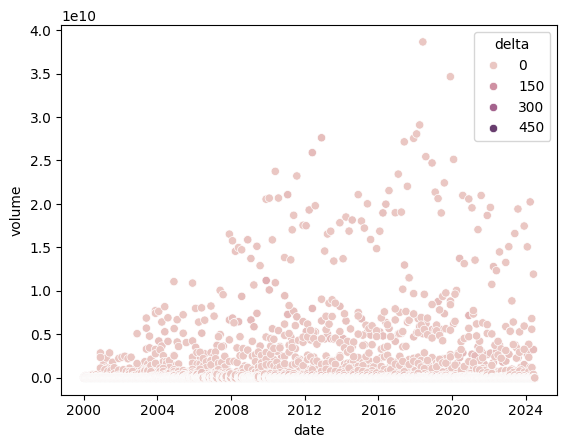

In [64]:
sns.scatterplot(df, x='date', y='volume', hue='delta')
plt.show()

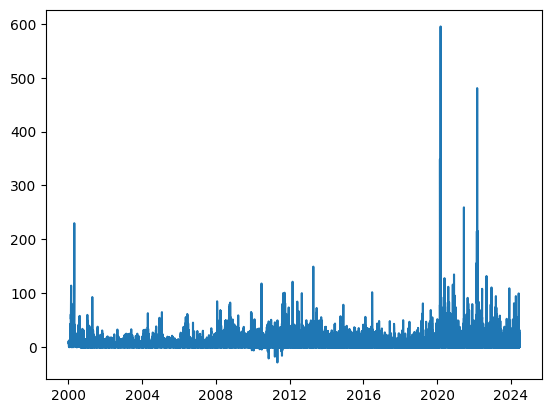

In [ ]:
plt.plot(df['date'], df['delta'])
plt.title('Изменение цены за день на протяжении всей истории записей')
plt.show()

<Axes: >

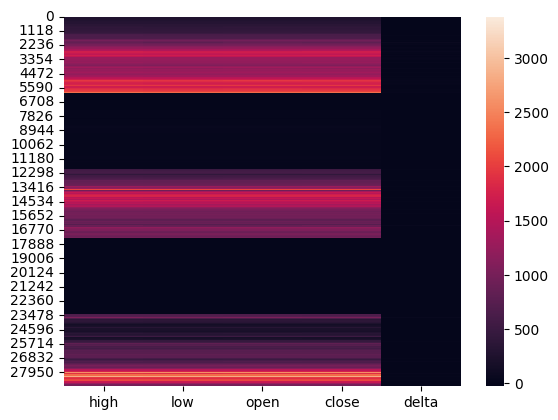

In [78]:
sns.heatmap(df[['high', 'low', 'open', 'close', 'delta']])

Text(0.5, 1.0, 'Кол-во сделок по металлам')

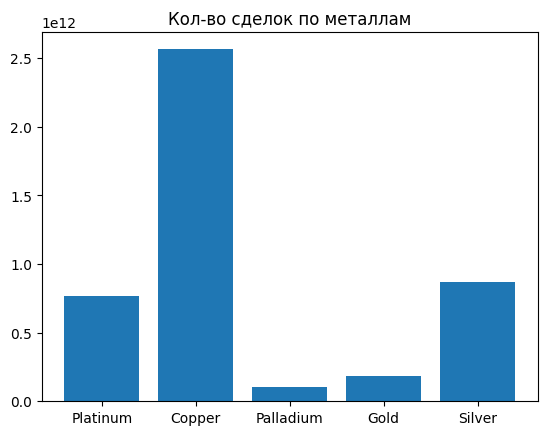

In [84]:
plt.bar(list(set(df['commodity'])), df.groupby('commodity')['volume'].sum())
plt.title('Кол-во сделок по металлам')

In [85]:
df.groupby('commodity')['open'].mean()

commodity
Copper          2.728696
Gold         1130.325975
Palladium     860.200757
Platinum     1057.117269
Silver         16.758749
Name: open, dtype: float64

In [86]:
df.groupby('commodity')['delta'].max()

commodity
Copper         0.452500
Gold         149.400024
Palladium    595.000000
Platinum     230.000000
Silver         6.478998
Name: delta, dtype: float64

In [93]:
pd.pivot_table(df, ['high', 'low', 'open', 'close', 'delta'], df['commodity'])

,close,delta,high,low,open
commodity,,,,,
Copper,2.729469,0.042384,2.749130,2.706747,2.728696
Gold,1130.246359,11.518109,1135.944854,1124.426745,1130.325975
Palladium,859.871204,5.365291,862.548346,857.183055,860.200757
Platinum,1057.512768,6.042900,1060.271964,1054.229064,1057.117269
Silver,16.752526,0.237805,16.871798,16.633993,16.758749
